In [71]:
from langgraph.graph import StateGraph, START, END
from langchain_google_genai import ChatGoogleGenerativeAI
from typing import TypedDict,Annotated
from dotenv import load_dotenv
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.graph.message import add_messages

In [72]:
load_dotenv()
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2
)

In [73]:
class ChatState(TypedDict):
    message: Annotated[list[BaseMessage], add_messages]

In [74]:
def chat_bot(state: ChatState):
    response = llm.invoke(state["message"])
    result = {'message': [response.content]}
    result
    return {'message': [response.content]}

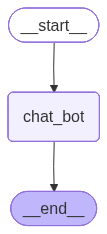

In [75]:
graph = StateGraph(ChatState)
graph.add_node('chat_bot', chat_bot)

graph.add_edge(START, 'chat_bot')
graph.add_edge('chat_bot', END)

workflow = graph.compile()
workflow

In [78]:
init_state = {'message': [HumanMessage(content="How are you AI?")]}
final_state = workflow.invoke(init_state)
final_state['message']

[HumanMessage(content='How are you AI?', additional_kwargs={}, response_metadata={}, id='a7b43163-3789-4836-a2be-53a87fb1059d'),
 HumanMessage(content='As an AI, I don\'t have feelings or a physical state, so I can\'t be "good" or "bad" in the human sense. However, I am functioning perfectly and ready to assist you!\n\nHow can I help you today?', additional_kwargs={}, response_metadata={}, id='931e237e-62a6-4782-884d-18dae71d5a7e')]

In [79]:
final_state['message'][-1].content

'As an AI, I don\'t have feelings or a physical state, so I can\'t be "good" or "bad" in the human sense. However, I am functioning perfectly and ready to assist you!\n\nHow can I help you today?'

In [1]:
# Persistance example
import pickle

In [ ]:
# Save chatbot state to disk
with open('chatbot_state.pkl', 'wb') as f:
    pickle.dump(final_state, f)
print("Chatbot state saved to chatbot_state.pkl")

In [ ]:
# Load chatbot state from disk and resume conversation
with open('chatbot_state.pkl', 'rb') as f:
    loaded_state = pickle.load(f)
resumed_state = workflow.invoke(loaded_state)
print("Resumed conversation:", resumed_state['message'])
